# Template Example Notebook

This is a template notebook. The first heading should be the title of what notebook is about. For example, if it is a project on neo4j tutorial the heading should be `Project Title`.

- Add description of what the notebook does.
- Point to references, e.g. (neo4j.example.md)
- Add citations.
- Keep the notebook flow clear.
- Comments should be imperative and have a period at the end.
- Your code should be well commented.

The name of this notebook should in the following format:
- if the notebook is exploring `pycaret API`, then it is `pycaret.example.ipynb`

Follow the reference to write notebooks in a clear manner: https://github.com/causify-ai/helpers/blob/master/docs/coding/all.jupyter_notebook.how_to_guide.md

In [39]:
# %load_ext autoreload
# %autoreload 2
# %matplotlib inline

In [40]:
# import logging
# # Import libraries in this section.
# # Avoid imports like import *, from ... import ..., from ... import *, etc.

# import helpers.hdbg as hdbg
# import helpers.hnotebook as hnotebo

In [41]:
# hdbg.init_logger(verbosity=logging.INFO)

# _LOG = logging.getLogger(__name__)

# hnotebo.config_notebook()

## Make the notebook flow clear
Each notebook needs to follow a clear and logical flow, e.g:
- Load data
- Compute stats
- Clean data
- Compute stats
- Do analysis
- Show results




#############################################################################
Template
#############################################################################

In [42]:
# class Template:
#     """
#     Brief imperative description of what the class does in one line, if needed.
#     """

#     def __init__(self):
#         pass

#     def method1(self, arg1: int) -> None:
#         """
#         Brief imperative description of what the method does in one line.

#         You can elaborate more in the method docstring in this section, for e.g. explaining
#         the formula/algorithm. Every method/function should have a docstring, typehints and include the
#         parameters and return as follows:

#         :param arg1: description of arg1
#         :return: description of return
#         """
#         # Code bloks go here.
#         # Make sure to include comments to explain what the code is doing.
#         # No empty lines between code blocks.
#         pass


# def template_function(arg1: int) -> None:
#     """
#     Brief imperative description of what the function does in one line.

#     You can elaborate more in the function docstring in this section, for e.g. explaining
#     the formula/algorithm. Every function should have a docstring, typehints and include the
#     parameters and return as follows:

#     :param arg1: description of arg1
#     :return: description of return
#     """
#     # Code bloks go here.
#     # Make sure to include comments to explain what the code is doing.
#     # No empty lines between code blocks.
#     pass

## The flow should be highlighted using headings in markdown
```
# Level 1
## Level 2
### Level 3
```

# Description

This notebook implements a full time series forecasting pipeline using the
Darts library to predict S&P 500 index prices and identify which market
sectors will outperform in the near future.

The notebook covers data collection for S&P 500, 11 sector ETFs, and 22
macroeconomic dimensions including yield curve, VIX, CPI, Fed rate, oil,
gold, and dollar index. It performs data preprocessing with release-date-aware
forward fill, feature engineering including technical indicators, calendar
features, and event flags for FOMC meetings, CPI release dates, and US
holidays. It trains the full Darts model suite across baseline, statistical,
probabilistic, and machine learning model groups, applies SHAP based feature
selection, performs hyperparameter tuning, builds ensemble models, and
benchmarks results against Facebook Prophet and Statsmodels. The sector
rotation engine recommends which sectors to rotate into based entirely on
model predictions, historical correlations, and risk adjusted scores.

References:
- Darts documentation: https://unit8co.github.io/darts/
- FRED API documentation: https://fred.stlouisfed.org/docs/api/fred/
- yfinance documentation: https://pypi.org/project/yfinance/
- Prophet documentation: https://facebook.github.io/prophet/

# Imports

In [43]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import logging
import os
import warnings

import darts
import darts.dataprocessing.transformers
import darts.metrics
import darts.models
import darts.timeseries
import dotenv
import fredapi
import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import prophet
import seaborn as sns
import shap
import sklearn.preprocessing
import statsmodels.tsa.arima.model
import statsmodels.tsa.holtwinters
import tqdm
import utils
import yfinance as yf

warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
# Configure the logger to track notebook execution.
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
)
_LOG = logging.getLogger(__name__)
# Log the environment setup confirmation and Darts version.
_LOG.info("Environment configured successfully.")
_LOG.info("Darts version: %s", darts.__version__)

2026-04-04 17:37:09,738 - INFO - Environment configured successfully.
2026-04-04 17:37:09,739 - INFO - Darts version: 0.43.0


# Configuration

In [45]:
# Define the date range for all data downloads.
START_DATE = "2018-01-01"
END_DATE = "2024-12-31"
# Define the S&P 500 ticker symbol.
SP500_TICKER = "^GSPC"
# Define all 11 sector ETF ticker symbols.
SECTOR_TICKERS = [
    "XLK",
    "XLV",
    "XLF",
    "XLE",
    "XLY",
    "XLP",
    "XLI",
    "XLU",
    "XLB",
    "XLRE",
    "XLC",
]
# Define sector names mapped to their ticker symbols.
SECTOR_NAMES = {
    "XLK": "Technology",
    "XLV": "Healthcare",
    "XLF": "Financials",
    "XLE": "Energy",
    "XLY": "Consumer Discretionary",
    "XLP": "Consumer Staples",
    "XLI": "Industrials",
    "XLU": "Utilities",
    "XLB": "Materials",
    "XLRE": "Real Estate",
    "XLC": "Communication Services",
}
# Define daily macro indicator ticker symbols from yfinance.
DAILY_MACRO_TICKERS = {
    "VIX": "^VIX",
    "TNX": "^TNX",
    "IRX": "^IRX",
    "OIL": "CL=F",
    "GOLD": "GC=F",
    "DXY": "DX-Y.NYB",
}
# Define monthly macro indicator codes from FRED API.
MONTHLY_MACRO_CODES = {
    "CPI": "CPIAUCSL",
    "CORE_CPI": "CPILFESL",
    "FED_RATE": "FEDFUNDS",
    "UNEMPLOYMENT": "UNRATE",
    "NFP": "PAYEMS",
    "RETAIL_SALES": "RSAFS",
    "INDUSTRIAL_PROD": "INDPRO",
    "PCE": "PCEPI",
    "PPI": "PPIACO",
}
# Define the FRED daily indicator code for breakeven inflation.
BREAKEVEN_INFLATION_CODE = "T10YIE"
# Define the data directory path for saving raw CSV files.
DATA_DIR = "data"
# Define the test set size in trading days.
TEST_SIZE = 60
# Define the validation set size in trading days.
VAL_SIZE = 60
# Define the forecast horizon in trading days.
FORECAST_HORIZON = 30
# Create the data directory if it does not exist.
os.makedirs(DATA_DIR, exist_ok=True)
_LOG.info("Configuration loaded successfully.")
_LOG.info("Date range: %s to %s", START_DATE, END_DATE)
_LOG.info("Sectors: %s", list(SECTOR_NAMES.values()))

2026-04-04 17:37:09,757 - INFO - Configuration loaded successfully.
2026-04-04 17:37:09,757 - INFO - Date range: 2018-01-01 to 2024-12-31
2026-04-04 17:37:09,757 - INFO - Sectors: ['Technology', 'Healthcare', 'Financials', 'Energy', 'Consumer Discretionary', 'Consumer Staples', 'Industrials', 'Utilities', 'Materials', 'Real Estate', 'Communication Services']


# Data collection

This section downloads all required data from Yahoo Finance and the FRED
API and saves it as raw CSV files in the `data` directory. The data
includes S&P 500 historical prices, 11 sector ETF prices, 6 daily
macroeconomic indicators, and 10 monthly macroeconomic indicators covering
the period from 2018 to 2024.

In [46]:
# Load environment variables from the .env file.
dotenv.load_dotenv()
# Read the FRED API key from the environment variables.
FRED_API_KEY = os.environ.get("FRED_API_KEY")
# Verify the FRED API key was loaded successfully.
if FRED_API_KEY is None:
    raise ValueError("FRED_API_KEY not found in .env file.")
_LOG.info("FRED API key loaded successfully.")

2026-04-04 17:37:09,773 - INFO - FRED API key loaded successfully.


In [47]:
# Load S&P 500 data from CSV if available otherwise download fresh.
if os.path.exists(os.path.join(DATA_DIR, "sp500_raw.csv")):
    sp500 = utils.load_data("sp500_raw.csv", DATA_DIR)
else:
    sp500 = utils.download_sp500(SP500_TICKER, START_DATE, END_DATE)
    utils.save_data(sp500, "sp500_raw.csv", DATA_DIR)
sp500.head(3)

2026-04-04 17:37:09,789 - INFO - Downloading S&P 500 data from 2018-01-01 to 2024-12-31.
2026-04-04 17:37:09,825 - INFO - Downloaded 1760 rows of S&P 500 data.
2026-04-04 17:37:09,832 - INFO - Saved 1760 rows to data/sp500_raw.csv.


Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,2695.810059,2695.889893,2682.360107,2683.729980,3397430000
2018-01-03,2713.060059,2714.370117,2697.770020,2697.850098,3544030000
2018-01-04,2723.989990,2729.290039,2719.070068,2719.310059,3697340000


In [48]:
# Load sector ETF data from CSV if available otherwise download fresh.
if os.path.exists(os.path.join(DATA_DIR, "sectors_raw.csv")):
    sectors = utils.load_data("sectors_raw.csv", DATA_DIR)
else:
    sectors = utils.download_sectors(SECTOR_TICKERS, START_DATE, END_DATE)
    utils.save_data(sectors, "sectors_raw.csv", DATA_DIR)
sectors.head(3)

2026-04-04 17:37:09,850 - INFO - Downloading 11 sector ETFs.
2026-04-04 17:37:09,997 - INFO - Downloaded 1760 rows for 11 sectors.
2026-04-04 17:37:10,006 - INFO - Saved 1760 rows to data/sectors_raw.csv.


,XLK,XLV,XLF,XLE,XLY,XLP,XLI,XLU,XLB,XLRE,XLC
Date,,,,,,,,,,,
2018-01-02,29.872921,72.723335,23.884142,25.747267,46.275246,45.314571,66.254837,20.132584,25.995680,24.837584,NaN
2018-01-03,30.122097,73.419182,24.012455,26.132853,46.487698,45.298527,66.611710,19.974422,26.177759,24.845165,NaN
2018-01-04,30.274364,73.523575,24.234877,26.290606,46.640129,45.426777,67.099136,19.808550,26.406427,24.420458,NaN


In [49]:
# Load daily macro data from CSV if available otherwise download fresh.
if os.path.exists(os.path.join(DATA_DIR, "macro_daily_raw.csv")):
    macro_daily = utils.load_data("macro_daily_raw.csv", DATA_DIR)
else:
    macro_daily = utils.download_daily_macro(
        DAILY_MACRO_TICKERS, START_DATE, END_DATE
    )
    utils.save_data(macro_daily, "macro_daily_raw.csv", DATA_DIR)
macro_daily.head(3)

2026-04-04 17:37:10,023 - INFO - Downloading 6 daily macro indicators.
2026-04-04 17:37:10,107 - INFO - Downloaded 1760 rows for 6 daily macro indicators.
2026-04-04 17:37:10,113 - INFO - Saved 1760 rows to data/macro_daily_raw.csv.


,VIX,TNX,IRX,OIL,GOLD,DXY
Date,,,,,,
2018-01-02,9.77,2.465,1.378,60.369999,1313.699951,91.849998
2018-01-03,9.15,2.447,1.370,61.630001,1316.199951,92.160004
2018-01-04,9.22,2.453,1.370,62.009998,1319.400024,91.849998


In [50]:
# Load monthly macro data from CSV if available otherwise download fresh.
if os.path.exists(os.path.join(DATA_DIR, "macro_monthly_raw.csv")):
    macro_monthly = utils.load_data("macro_monthly_raw.csv", DATA_DIR)
else:
    macro_monthly = utils.download_monthly_macro(
        MONTHLY_MACRO_CODES,
        BREAKEVEN_INFLATION_CODE,
        START_DATE,
        END_DATE,
        FRED_API_KEY,
    )
    utils.save_data(macro_monthly, "macro_monthly_raw.csv", DATA_DIR)
macro_monthly.head(3)

2026-04-04 17:37:10,128 - INFO - Downloading 9 monthly macro indicators from FRED.
2026-04-04 17:37:12,260 - INFO - Downloading 10Y breakeven inflation from FRED.
2026-04-04 17:37:12,562 - INFO - Downloaded 1850 rows for 10 monthly macro indicators.
2026-04-04 17:37:12,567 - INFO - Saved 1850 rows to data/macro_monthly_raw.csv.


,CPI,CORE_CPI,FED_RATE,UNEMPLOYMENT,NFP,RETAIL_SALES,INDUSTRIAL_PROD,PCE,PPI,BREAKEVEN
Date,,,,,,,,,,
2018-01-01,248.859,255.204,1.41,4.0,147660.0,481414.0,101.4625,101.199,197.9,NaN
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00
2018-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.98


# Data preprocessing and EDA

This section cleans and aligns all downloaded datasets, applies
release-date-aware forward fill to monthly macro indicators, adds
binary release flags to distinguish actual data release days from
forward filled values, and performs exploratory data analysis to
understand the structure and patterns in the data before modeling.

## Align datasets to common date index

In [51]:
# Use S&P 500 date index as the master index for all datasets.
master_index = sp500.index
# Reindex daily datasets directly — no monthly values to preserve.
sectors = sectors.reindex(master_index)
macro_daily = macro_daily.reindex(master_index)
# Preserve monthly values before reindexing to avoid losing data
# that falls on non trading days like weekends and holidays.
macro_monthly = utils.preserve_month_start_values(
    macro_monthly, master_index
)
# Verify all datasets have the same shape after alignment.
_LOG.info("S&P 500 shape: %s", sp500.shape)
_LOG.info("Sectors shape: %s", sectors.shape)
_LOG.info("Macro daily shape: %s", macro_daily.shape)
_LOG.info("Macro monthly shape: %s", macro_monthly.shape)

2026-04-04 17:37:12,586 - INFO - S&P 500 shape: (1760, 5)
2026-04-04 17:37:12,587 - INFO - Sectors shape: (1760, 11)
2026-04-04 17:37:12,587 - INFO - Macro daily shape: (1760, 6)
2026-04-04 17:37:12,587 - INFO - Macro monthly shape: (1760, 10)


## Apply release-date-aware forward fill to monthly indicators

In [52]:
# Apply release-date-aware forward fill to monthly macro indicators.
macro_monthly = utils.apply_release_aware_forward_fill(
    macro_monthly,
    FRED_API_KEY,
    MONTHLY_MACRO_CODES,
)
# Preview the result to verify forward fill worked correctly.
macro_monthly.head(20)

2026-04-04 17:37:12,601 - INFO - Applying release-date-aware forward fill using vintage dates.
Forward filling indicators: 100%|█████████████████| 9/9 [00:02<00:00,  3.48it/s]
2026-04-04 17:37:15,190 - INFO - Forward fill complete for 9 indicators.


,CPI,CORE_CPI,FED_RATE,UNEMPLOYMENT,NFP,RETAIL_SALES,INDUSTRIAL_PROD,PCE,PPI,BREAKEVEN,CPI_released,CORE_CPI_released,FED_RATE_released,UNEMPLOYMENT_released,NFP_released,RETAIL_SALES_released,INDUSTRIAL_PROD_released,PCE_released,PPI_released
Date,,,,,,,,,,,,,,,,,,,
2018-01-02,NaN,NaN,1.41,NaN,NaN,NaN,NaN,NaN,NaN,2.00,0,0,1,0,0,0,0,0,0
2018-01-03,NaN,NaN,1.41,NaN,NaN,NaN,NaN,NaN,NaN,1.98,0,0,0,0,0,0,0,0,0
2018-01-04,NaN,NaN,1.41,NaN,NaN,NaN,NaN,NaN,NaN,2.01,0,0,0,0,0,0,0,0,0
2018-01-05,NaN,NaN,1.41,4.0,147660.0,NaN,NaN,NaN,NaN,2.01,0,0,0,1,1,0,0,0,0
2018-01-08,NaN,NaN,1.41,4.0,147660.0,NaN,NaN,NaN,NaN,2.02,0,0,0,0,0,0,0,0,0
2018-01-09,NaN,NaN,1.41,4.0,147660.0,NaN,NaN,NaN,NaN,2.03,0,0,0,0,0,0,0,0,0
2018-01-10,NaN,NaN,1.41,4.0,147660.0,NaN,NaN,NaN,NaN,2.03,0,0,0,0,0,0,0,0,0
2018-01-11,NaN,NaN,1.41,4.0,147660.0,NaN,NaN,NaN,197.9,2.00,0,0,0,0,0,0,0,0,1
2018-01-12,248.859,255.204,1.41,4.0,147660.0,481414.0,NaN,NaN,197.9,2.01,1,1,0,0,0,1,0,0,0


In [53]:
# Check when the first non-NaN values appear for each indicator.
first_valid = macro_monthly.apply(lambda col: col.first_valid_index())
_LOG.info("First valid date per indicator:\n%s", first_valid.to_string())

2026-04-04 17:37:15,222 - INFO - First valid date per indicator:
CPI                        2018-01-12
CORE_CPI                   2018-01-12
FED_RATE                   2018-01-02
UNEMPLOYMENT               2018-01-05
NFP                        2018-01-05
RETAIL_SALES               2018-01-12
INDUSTRIAL_PROD            2018-01-17
PCE                        2018-01-29
PPI                        2018-01-11
BREAKEVEN                  2018-01-02
CPI_released               2018-01-02
CORE_CPI_released          2018-01-02
FED_RATE_released          2018-01-02
UNEMPLOYMENT_released      2018-01-02
NFP_released               2018-01-02
RETAIL_SALES_released      2018-01-02
INDUSTRIAL_PROD_released   2018-01-02
PCE_released               2018-01-02
PPI_released               2018-01-02


In [54]:
# Verify the forward fill and release flags worked correctly.
_LOG.info("Macro monthly shape: %s", macro_monthly.shape)
_LOG.info("Total NaN values remaining: %d", macro_monthly.isnull().sum().sum())
_LOG.info("Release flag columns: %s", 
    [col for col in macro_monthly.columns if col.endswith("_released")]
)
# Show a sample around a known release date to verify flags.
macro_monthly.loc["2018-01-01":"2018-02-05", ["CPI", "CPI_released"]].head(10)

2026-04-04 17:37:15,238 - INFO - Macro monthly shape: (1760, 19)
2026-04-04 17:37:15,239 - INFO - Total NaN values remaining: 65
2026-04-04 17:37:15,239 - INFO - Release flag columns: ['CPI_released', 'CORE_CPI_released', 'FED_RATE_released', 'UNEMPLOYMENT_released', 'NFP_released', 'RETAIL_SALES_released', 'INDUSTRIAL_PROD_released', 'PCE_released', 'PPI_released']


,CPI,CPI_released
Date,,
2018-01-02,NaN,0
2018-01-03,NaN,0
2018-01-04,NaN,0
2018-01-05,NaN,0
2018-01-08,NaN,0
2018-01-09,NaN,0
2018-01-10,NaN,0
2018-01-11,NaN,0
2018-01-12,248.859,1


In [55]:
# Verify CPI release flag shows 1 on actual release days.
cpi_releases = macro_monthly[macro_monthly["CPI_released"] == 1]["CPI"]
_LOG.info(
    "Number of actual CPI release days: %d", len(cpi_releases)
)
_LOG.info(
    "First few CPI release dates:\n%s", cpi_releases.head(5).to_string()
)

2026-04-04 17:37:15,257 - INFO - Number of actual CPI release days: 90
2026-04-04 17:37:15,258 - INFO - First few CPI release dates:
Date
2018-01-12    248.859
2018-02-14    249.529
2018-03-13    249.577
2018-04-11    250.227
2018-05-10    250.792


In [56]:
# Check fredapi version and available methods.
import fredapi
_LOG.info("fredapi version: %s", fredapi.__version__)
fred_temp = fredapi.Fred(api_key=FRED_API_KEY)
fred_methods = [m for m in dir(fred_temp) if not m.startswith("_")]
_LOG.info("Available methods: %s", fred_methods)

2026-04-04 17:37:15,272 - INFO - fredapi version: 0.5.2
2026-04-04 17:37:15,272 - INFO - Available methods: ['api_key', 'earliest_realtime_start', 'get_series', 'get_series_all_releases', 'get_series_as_of_date', 'get_series_first_release', 'get_series_info', 'get_series_latest_release', 'get_series_vintage_dates', 'latest_realtime_end', 'max_results_per_request', 'nan_char', 'proxies', 'root_url', 'search', 'search_by_category', 'search_by_release']


In [57]:
# Verify CPI release flag shows 1 on true release days.
cpi_releases = macro_monthly[macro_monthly["CPI_released"] == 1]["CPI"]
_LOG.info("Number of actual CPI release days: %d", len(cpi_releases))
_LOG.info(
    "First few CPI release dates:\n%s", cpi_releases.head(5).to_string()
)
# Verify total NaN values remaining.
_LOG.info(
    "Total NaN values remaining: %d",
    macro_monthly.isnull().sum().sum()
)

2026-04-04 17:37:15,287 - INFO - Number of actual CPI release days: 90
2026-04-04 17:37:15,288 - INFO - First few CPI release dates:
Date
2018-01-12    248.859
2018-02-14    249.529
2018-03-13    249.577
2018-04-11    250.227
2018-05-10    250.792
2026-04-04 17:37:15,288 - INFO - Total NaN values remaining: 65


In [58]:
# Identify which columns still have NaN values and how many.
nan_counts = macro_monthly.isnull().sum()
nan_counts = nan_counts[nan_counts > 0]
_LOG.info("Columns with remaining NaN values:\n%s", nan_counts.to_string())

2026-04-04 17:37:15,303 - INFO - Columns with remaining NaN values:
CPI                 8
CORE_CPI            8
UNEMPLOYMENT        3
NFP                 3
RETAIL_SALES        8
INDUSTRIAL_PROD    10
PCE                18
PPI                 7


In [59]:
# Find the first date where all monthly macro indicators have values.
first_complete_date = macro_monthly.dropna().index[0]
_LOG.info(
    "First date with complete macro data: %s", first_complete_date
)
# Count how many rows we lose by starting from this date.
rows_before = len(macro_monthly)
rows_after = len(macro_monthly.loc[first_complete_date:])
rows_dropped = rows_before - rows_after
_LOG.info(
    "Rows dropped: %d (%.2f%% of total)",
    rows_dropped,
    rows_dropped / rows_before * 100,
)

2026-04-04 17:37:15,318 - INFO - First date with complete macro data: 2018-01-29 00:00:00
2026-04-04 17:37:15,318 - INFO - Rows dropped: 18 (1.02% of total)


## Trim datasets to first complete macro data date

In [60]:
# Trim all datasets to start from the first date where all macro
# indicators have complete values to eliminate initial NaN period.
sp500 = sp500.loc[first_complete_date:]
sectors = sectors.loc[first_complete_date:]
macro_daily = macro_daily.loc[first_complete_date:]
macro_monthly = macro_monthly.loc[first_complete_date:]
# Show percentage of rows dropped across all datasets.
_LOG.info(
    "Rows dropped: %d (%.2f%% of total)",
    rows_dropped,
    rows_dropped / rows_before * 100,
)
# Verify all datasets have the same shape after trimming.
_LOG.info("S&P 500 shape after trim: %s", sp500.shape)
_LOG.info("Sectors shape after trim: %s", sectors.shape)
_LOG.info("Macro daily shape after trim: %s", macro_daily.shape)
_LOG.info("Macro monthly shape after trim: %s", macro_monthly.shape)
# Verify no NaN values remain in monthly macro data.
_LOG.info(
    "NaN values remaining in macro monthly: %d",
    macro_monthly.isnull().sum().sum()
)

2026-04-04 17:37:15,333 - INFO - Rows dropped: 18 (1.02% of total)
2026-04-04 17:37:15,333 - INFO - S&P 500 shape after trim: (1742, 5)
2026-04-04 17:37:15,333 - INFO - Sectors shape after trim: (1742, 11)
2026-04-04 17:37:15,333 - INFO - Macro daily shape after trim: (1742, 6)
2026-04-04 17:37:15,334 - INFO - Macro monthly shape after trim: (1742, 19)
2026-04-04 17:37:15,334 - INFO - NaN values remaining in macro monthly: 0


## Reconstruct XLC pre-launch history

XLC (Communication Services ETF) launched on June 19 2018. To preserve
the full analysis period from January 2018, pre-launch XLC values are
reconstructed using historical prices of the top 12 XLC constituent
companies weighted by market capitalization at each point in time.

The reconstruction is validated against actual XLC prices for the
overlap period from June 2018 onwards. If the correlation exceeds
0.90 the reconstruction replaces NaN values in the sectors DataFrame.
If correlation falls below 0.90 the dataset is trimmed to June 2018
as a fallback — ensuring we never use an unreliable reconstruction.

References:
- XLC constituent data: https://www.ssga.com/us/en/intermediary/etfs/funds/the-communication-services-select-sector-spdr-fund-xlc

In [61]:
# Define XLC launch date as the first valid date in the sectors data.
xlc_first_date = pd.Timestamp("2018-06-19")
# Reconstruct XLC pre-launch history using verified constituent weights
# from the official SPDR ETF filing on June 19 2018.
sectors = utils.reconstruct_xlc(
    sectors,
    START_DATE,
    str(xlc_first_date.date()),
    correlation_threshold=0.90,
)
# Verify XLC NaN values are resolved after reconstruction.
xlc_nan_remaining = sectors["XLC"].isnull().sum()
_LOG.info(
    "XLC NaN values remaining after reconstruction: %d",
    xlc_nan_remaining,
)
# Show percentage of rows that were reconstructed.
_LOG.info(
    "XLC rows reconstructed: %d (%.2f%% of total)",
    98 - xlc_nan_remaining,
    (98 - xlc_nan_remaining) / len(sectors) * 100,
)
# Preview XLC values around the reconstruction period.
sectors[["XLC"]].loc[
    sectors.index[sectors.index < pd.Timestamp(xlc_first_date)]
].tail(10)

2026-04-04 17:37:15,348 - INFO - Downloading XLC constituent stock prices.
2026-04-04 17:37:15,377 - INFO - Downloaded GOOGL successfully.
2026-04-04 17:37:15,391 - INFO - Downloaded GOOG successfully.
2026-04-04 17:37:15,405 - INFO - Downloaded DIS successfully.
2026-04-04 17:37:15,418 - INFO - Downloaded CMCSA successfully.
2026-04-04 17:37:15,432 - INFO - Downloaded NFLX successfully.
2026-04-04 17:37:15,446 - INFO - Downloaded T successfully.
2026-04-04 17:37:15,459 - INFO - Downloaded VZ successfully.
2026-04-04 17:37:15,487 - INFO - Downloaded EA successfully.
2026-04-04 17:37:15,501 - INFO - Downloaded TTWO successfully.
2026-04-04 17:37:15,515 - INFO - Downloaded OMC successfully.
2026-04-04 17:37:15,527 - INFO - Downloaded TMUS successfully.
2026-04-04 17:37:15,541 - INFO - Downloaded TRIP successfully.
2026-04-04 17:37:15,555 - INFO - Downloaded NWSA successfully.
2026-04-04 17:37:15,568 - INFO - Downloaded LUMN successfully.
2026-04-04 17:37:15,569 - INFO - Using 16 constitu

,XLC
Date,
2018-06-05,44.523974
2018-06-06,44.625140
2018-06-07,44.287411
2018-06-08,44.416398
2018-06-11,44.915994
2018-06-12,45.284422
2018-06-13,45.258196
2018-06-14,46.302530
2018-06-15,46.281124


In [62]:
# Verify the full sectors DataFrame has zero NaN values.
_LOG.info(
    "Total NaN values in sectors: %d",
    sectors.isnull().sum().sum()
)
# Verify all sectors start from the same date.
_LOG.info("Sectors date range: %s to %s",
    sectors.index[0].date(),
    sectors.index[-1].date()
)
# Preview sectors DataFrame.
sectors.head(10)

2026-04-04 17:37:15,588 - INFO - Total NaN values in sectors: 0
2026-04-04 17:37:15,588 - INFO - Sectors date range: 2018-01-29 to 2024-12-30


,XLK,XLV,XLF,XLE,XLY,XLP,XLI,XLU,XLB,XLRE,XLC
Date,,,,,,,,,,,
2018-01-29,31.635572,79.403351,25.706249,26.760326,50.205780,46.869396,69.736435,19.438225,26.829884,24.109522,46.636041
2018-01-30,31.349482,77.733353,25.372620,26.220499,49.956383,46.556831,69.188095,19.472944,26.635086,24.010925,46.672748
2018-01-31,31.584833,76.628708,25.441057,26.238018,49.794720,46.340427,69.396988,19.688969,26.656263,24.503889,46.854588
2018-02-01,31.612507,76.654816,25.680582,26.507940,49.240475,46.140068,69.275108,19.380367,26.292093,24.056429,47.396782
2018-02-02,30.675812,75.576256,25.115988,25.400230,48.769360,45.258465,67.882484,19.241491,25.601873,23.783401,46.879370
2018-02-05,29.393036,72.227570,23.849928,24.334572,47.125080,43.615471,64.801254,18.925165,24.623695,23.169096,44.847900
2018-02-06,30.237453,73.027748,24.286200,24.527378,48.330574,44.096348,65.985031,18.643566,25.428249,23.123596,45.537890
2018-02-07,29.849859,72.940796,24.303308,24.117247,48.182774,43.903988,66.106857,18.554838,25.199587,23.017420,44.635575
2018-02-08,28.613214,70.409683,23.233999,23.388121,46.261375,42.958271,63.556606,18.346531,24.314571,22.296947,42.559569


## Check and handle missing values in daily macro indicators

In [63]:
# Check missing values across all datasets before proceeding.
_LOG.info("Checking missing values across all datasets.")
# Count NaN values per column for each dataset.
sp500_nan = sp500.isnull().sum()
sectors_nan = sectors.isnull().sum()
macro_daily_nan = macro_daily.isnull().sum()
macro_monthly_nan = macro_monthly.isnull().sum()
# Log results for each dataset.
_LOG.info(
    "S&P 500 missing values:\n%s", sp500_nan[sp500_nan > 0].to_string()
)
_LOG.info(
    "Sectors missing values:\n%s",
    sectors_nan[sectors_nan > 0].to_string()
)
_LOG.info(
    "Macro daily missing values:\n%s",
    macro_daily_nan[macro_daily_nan > 0].to_string()
)
_LOG.info(
    "Macro monthly missing values:\n%s",
    macro_monthly_nan[macro_monthly_nan > 0].to_string()
)
# Log total missing values across all datasets.
total_nan = (
    sp500_nan.sum()
    + sectors_nan.sum()
    + macro_daily_nan.sum()
    + macro_monthly_nan.sum()
)
_LOG.info("Total missing values across all datasets: %d", total_nan)

2026-04-04 17:37:15,606 - INFO - Checking missing values across all datasets.
2026-04-04 17:37:15,607 - INFO - S&P 500 missing values:
Series([], )
2026-04-04 17:37:15,608 - INFO - Sectors missing values:
Series([], )
2026-04-04 17:37:15,608 - INFO - Macro daily missing values:
GOLD    1
2026-04-04 17:37:15,608 - INFO - Macro monthly missing values:
Series([], )
2026-04-04 17:37:15,609 - INFO - Total missing values across all datasets: 1


In [64]:
# Forward fill any remaining missing values in daily macro indicators.
# Single missing values in daily data are caused by occasional gaps
# in yfinance data — forward fill is the correct approach here.
macro_daily = macro_daily.ffill()
# Verify no missing values remain after forward fill.
_LOG.info(
    "Missing values after forward fill: %d",
    macro_daily.isnull().sum().sum(),
)

2026-04-04 17:37:15,623 - INFO - Missing values after forward fill: 1


In [65]:
# Find the exact location of the remaining missing value.
missing_location = macro_daily[macro_daily["GOLD"].isnull()]
_LOG.info(
    "Missing GOLD value location:\n%s",
    missing_location[["GOLD"]].to_string()
)

2026-04-04 17:37:15,638 - INFO - Missing GOLD value location:
            GOLD
Date            
2018-01-29   NaN


In [66]:
# Forward fill any remaining missing values in daily macro indicators.
# Single missing values in daily data are caused by occasional gaps
# in yfinance data — forward fill is the correct approach here.
macro_daily = macro_daily.ffill()
# Backward fill any remaining missing values at the start of the
# dataset where forward fill cannot work due to no prior values.
macro_daily = macro_daily.bfill()
# Verify no missing values remain after both fill operations.
_LOG.info(
    "Missing values after forward and backward fill: %d",
    macro_daily.isnull().sum().sum(),
)

2026-04-04 17:37:15,653 - INFO - Missing values after forward and backward fill: 0


In [67]:
# Save all processed datasets to CSV so preprocessing never needs
# to be rerun on every kernel restart.
utils.save_data(sp500, "sp500_processed.csv", DATA_DIR)
utils.save_data(sectors, "sectors_processed.csv", DATA_DIR)
utils.save_data(macro_daily, "macro_daily_processed.csv", DATA_DIR)
utils.save_data(macro_monthly, "macro_monthly_processed.csv", DATA_DIR)
_LOG.info("All processed datasets saved successfully.")

2026-04-04 17:37:15,670 - INFO - Saved 1742 rows to data/sp500_processed.csv.
2026-04-04 17:37:15,680 - INFO - Saved 1742 rows to data/sectors_processed.csv.
2026-04-04 17:37:15,685 - INFO - Saved 1742 rows to data/macro_daily_processed.csv.
2026-04-04 17:37:15,691 - INFO - Saved 1742 rows to data/macro_monthly_processed.csv.
2026-04-04 17:37:15,691 - INFO - All processed datasets saved successfully.


# Exploratory data analysis

This section visualizes the structure and patterns in our cleaned
datasets before modeling. The analysis covers S&P 500 price history
and returns, sector performance comparison, macroeconomic indicator
trends, and correlations between macro signals and market returns.
These insights directly inform our feature engineering and model
selection decisions.

## S&P 500 price history and daily returns

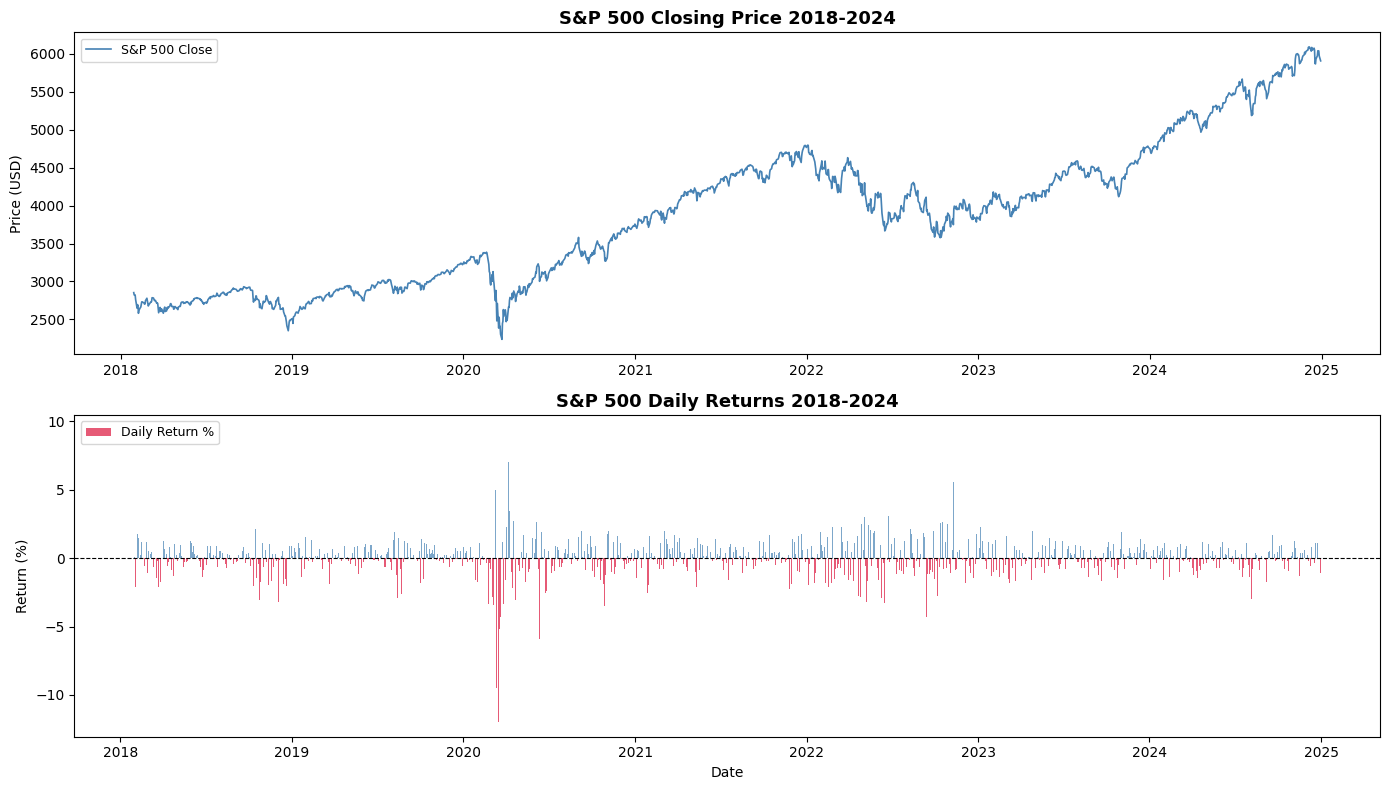

In [68]:
# Plot S&P 500 price history and daily returns.
fig = utils.plot_sp500_history(sp500)
plt.show()

## Sector performance comparison

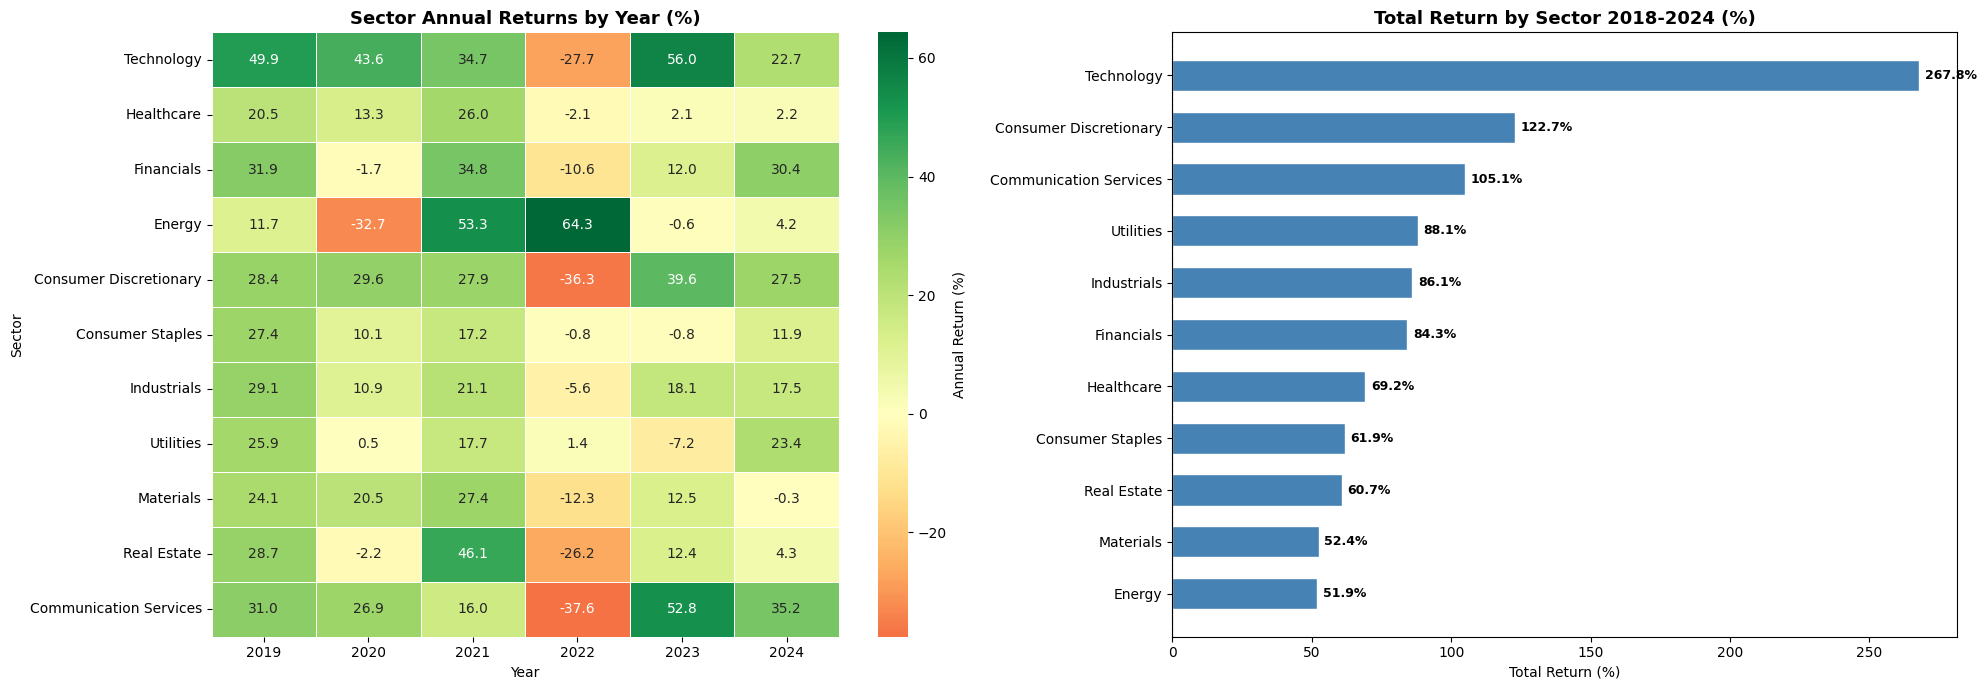

In [69]:
# Plot normalized cumulative performance of all 11 sector ETFs.
fig = utils.plot_sector_performance(sectors, SECTOR_NAMES)
plt.show()

## Macroeconomic indicator trends

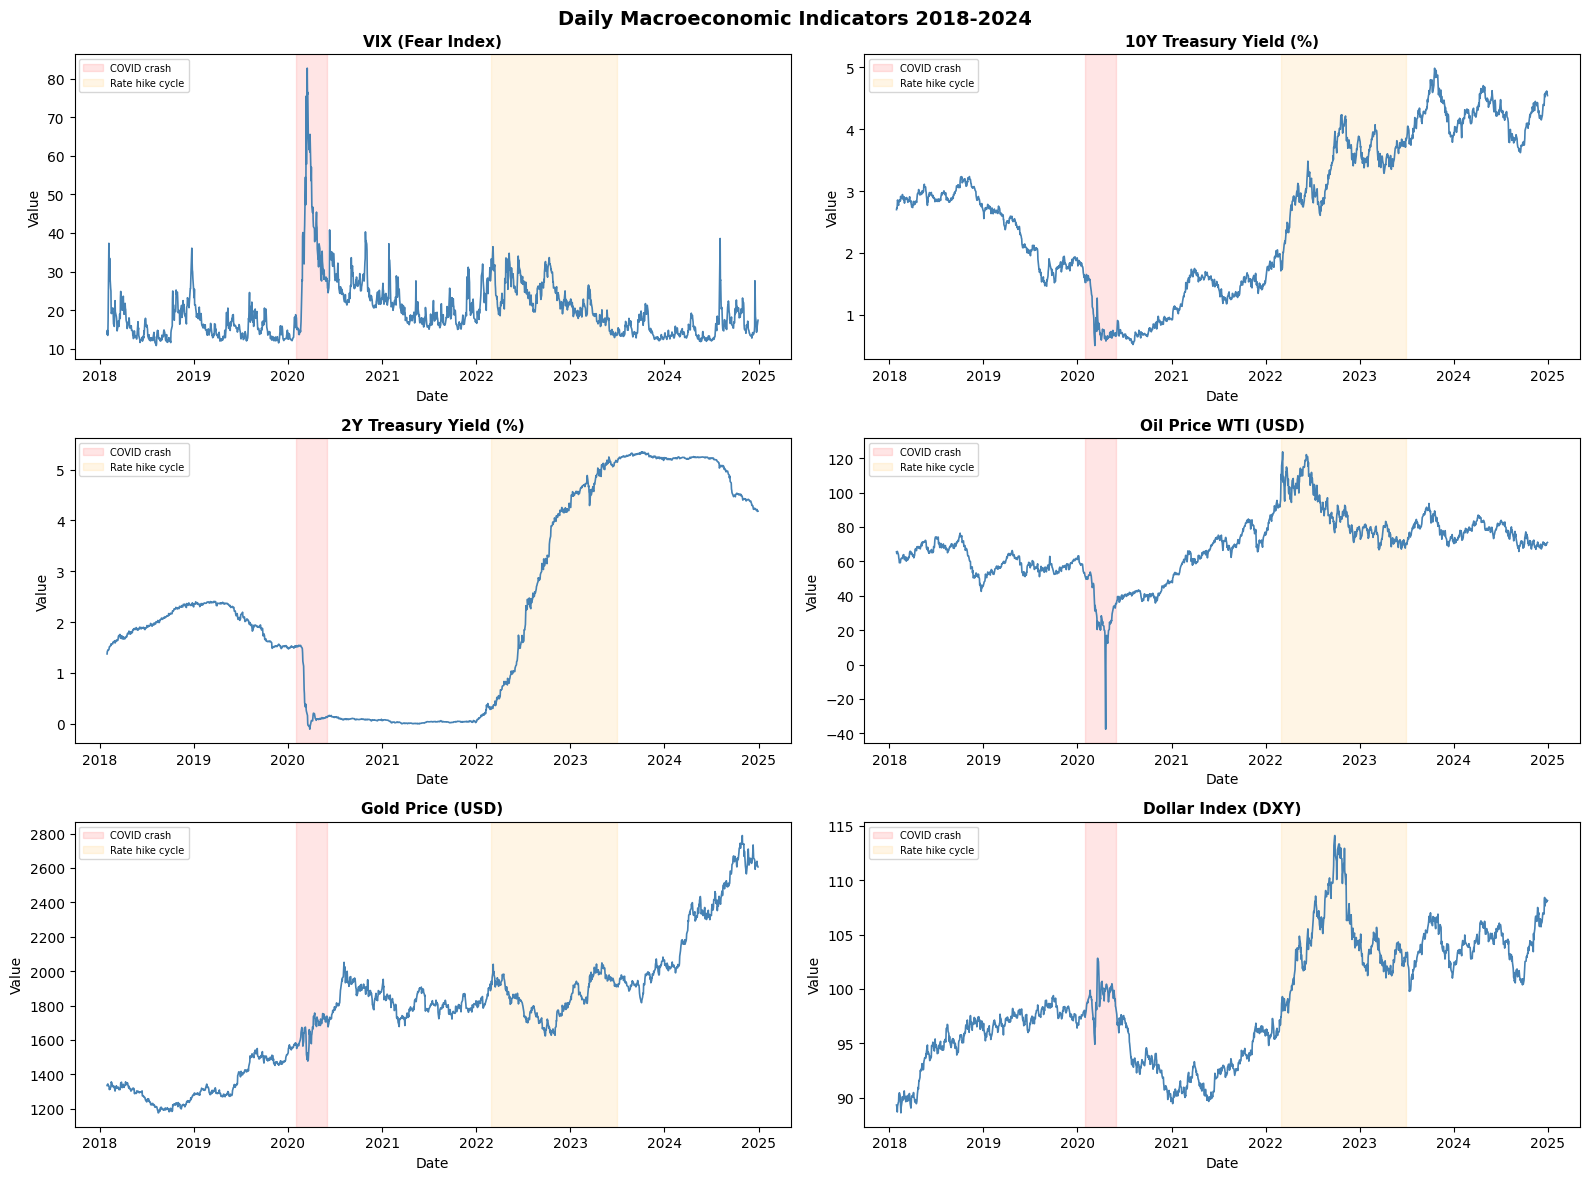

In [70]:
# Plot daily macroeconomic indicator trends with key market events highlighted.
fig = utils.plot_macro_trends(macro_daily, macro_monthly)
plt.show()

## Correlation between macro indicators and S&P 500 returns

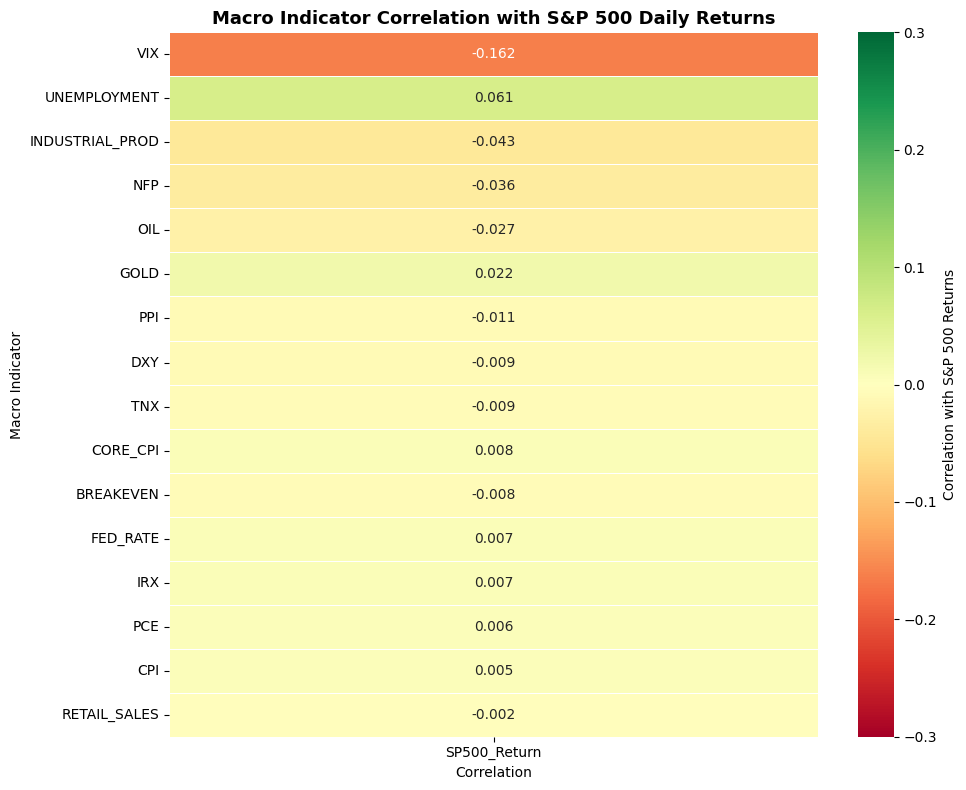

In [71]:
# Plot correlation between macro indicators and S&P 500 daily returns.
fig = utils.plot_macro_correlation(sp500, macro_daily, macro_monthly)
plt.show()

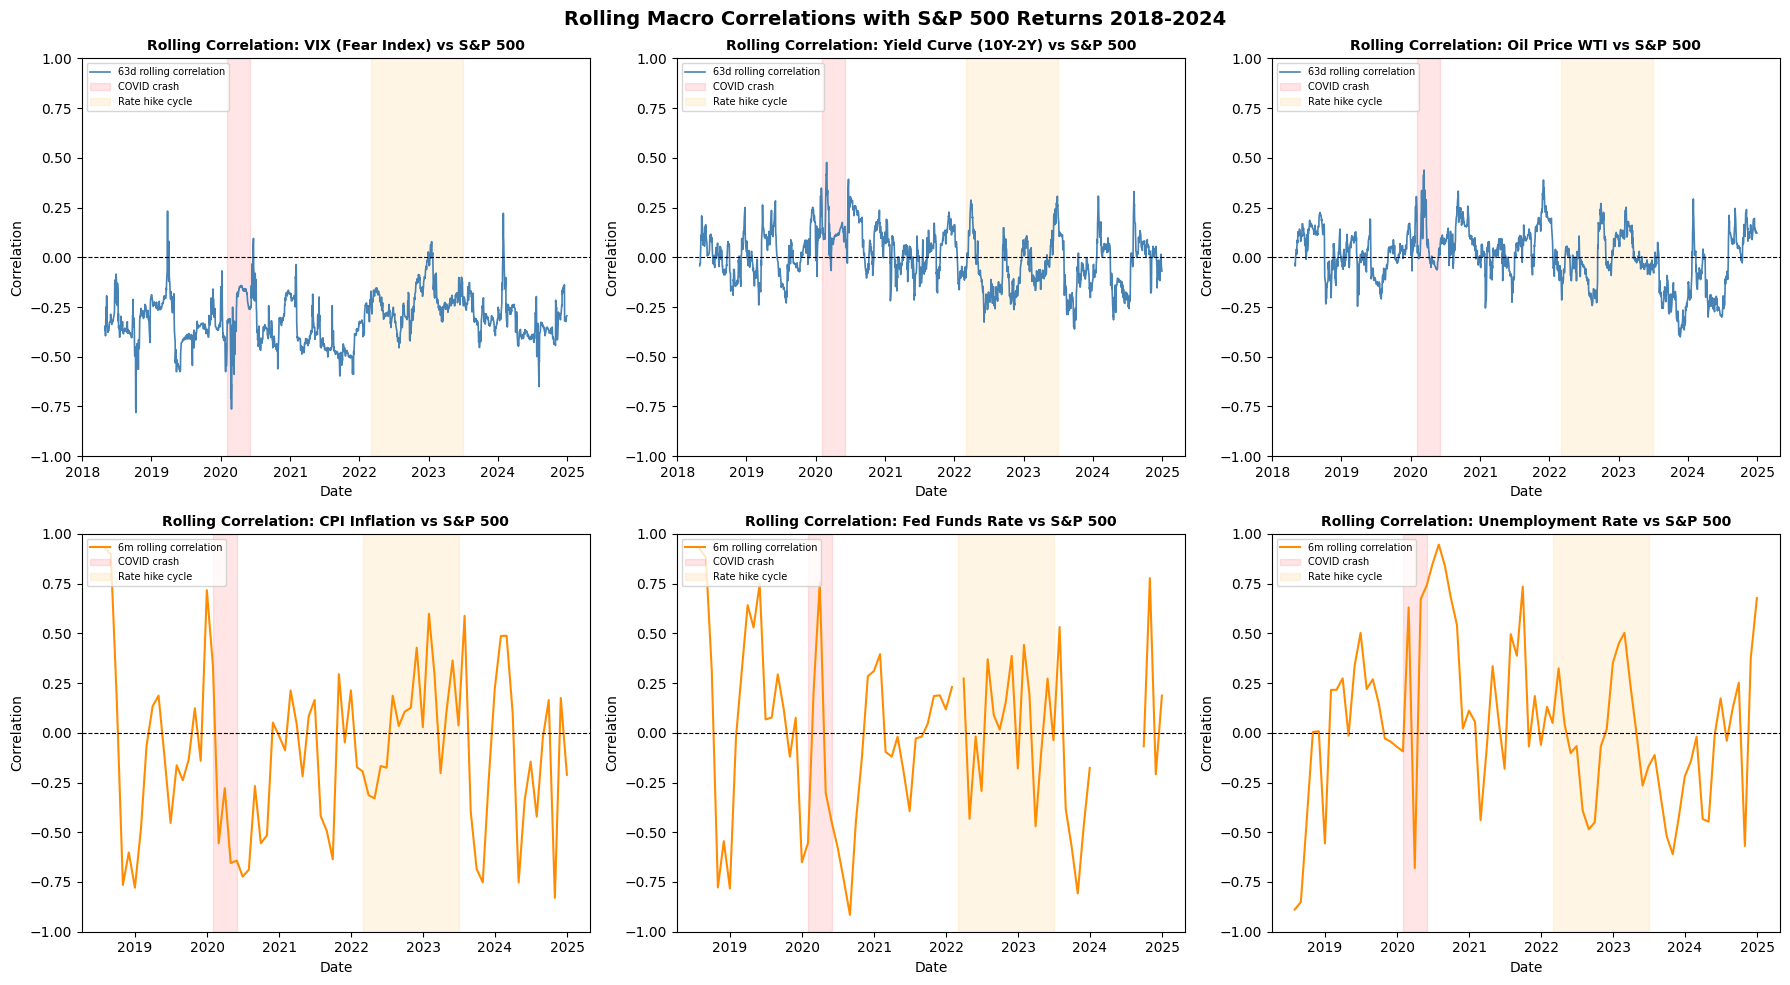

In [72]:
# Plot rolling correlations between key macro indicators and S&P 500
# to reveal how relationships change across different market regimes.
fig = utils.plot_rolling_correlations(sp500, macro_daily, macro_monthly)
plt.show()

# Feature engineering

This section builds all features used by our forecasting models.
Calculated macro features are derived from downloaded indicators.
Technical indicators capture price momentum and volatility patterns.
Calendar features encode seasonal patterns. Event flags mark dates
of known market moving events including FOMC meetings, CPI releases,
and US holidays. All features are then assembled into Darts TimeSeries
objects and split into train, validation, and test sets.

## Calculated macro features

In [100]:
# Calculate derived macro features from downloaded indicators.
macro_features = utils.calculate_macro_features(
    macro_daily, macro_monthly
)
# Show percentage of rows with NaN values after calculation.
nan_count = macro_features.isnull().sum().sum()
_LOG.info(
    "NaN values in calculated macro features: %d", nan_count
)
# Preview the calculated features.
macro_features.head(5)

2026-04-04 20:21:37,470 - INFO - NaN values in calculated macro features: 0


,YIELD_CURVE,YIELD_CURVE_INVERTED,CPI_MOM,VIX_MA20,OIL_MOM30,NFP_MOM
Date,,,,,,
2018-01-29,1.324,0,0.0,21.528,-7.397801,0.0
2018-01-30,1.301,0,0.0,21.528,-7.397801,0.0
2018-01-31,1.290,0,0.0,21.528,-7.397801,0.0
2018-02-01,1.320,0,0.0,21.528,-7.397801,0.0
2018-02-02,1.404,0,0.0,21.528,-7.397801,394.0


## Technical indicators

In [101]:
# Calculate technical indicators from S&P 500 closing prices.
technical_features = utils.calculate_technical_indicators(sp500)
# Verify no NaN values in technical indicators.
_LOG.info(
    "NaN values in technical indicators: %d",
    technical_features.isnull().sum().sum(),
)
# Preview the technical indicators.
technical_features.head(3)

2026-04-04 20:21:37,495 - INFO - NaN values in technical indicators: 0


,MA5,MA20,MA50,EMA12,EMA26,MACD,RSI,BB_UPPER,BB_LOWER
Date,,,,,,,,,
2018-01-29,2816.775977,2721.980481,2700.686597,2853.530029,2853.530029,0.000000,38.311073,2867.614772,2576.34619
2018-01-30,2816.775977,2721.980481,2700.686597,2848.745399,2851.226318,-2.480919,38.311073,2867.614772,2576.34619
2018-01-31,2816.775977,2721.980481,2700.686597,2844.909193,2849.195484,-4.286292,38.311073,2867.614772,2576.34619


## Calendar features

In [102]:
# Calculate calendar features from the aligned date index.
calendar_features = utils.calculate_calendar_features(sp500.index)
# Verify no NaN values in calendar features.
_LOG.info(
    "NaN values in calendar features: %d",
    calendar_features.isnull().sum().sum(),
)
# Preview the calendar features.
calendar_features.head(3)

2026-04-04 20:21:37,518 - INFO - NaN values in calendar features: 0


,DAY_OF_WEEK,MONTH,QUARTER
Date,,,
2018-01-29,0,1,1
2018-01-30,1,1,1
2018-01-31,2,1,1


## Event flags

In [103]:
# Calculate event flags for US holidays, FOMC dates, and CPI releases.
event_flags = utils.calculate_event_flags(sp500.index, FRED_API_KEY)
# Verify no NaN values in event flags.
_LOG.info(
    "NaN values in event flags: %d",
    event_flags.isnull().sum().sum(),
)
# Preview the event flags.
event_flags.head(5)

2026-04-04 20:21:38,098 - INFO - Holiday adjacent days: 107
2026-04-04 20:21:38,099 - INFO - FOMC meeting dates: 86
2026-04-04 20:21:38,099 - INFO - CPI release dates: 88
2026-04-04 20:21:38,100 - INFO - NaN values in event flags: 0


,IS_HOLIDAY_ADJACENT,IS_FOMC_DATE,IS_CPI_RELEASE
Date,,,
2018-01-29,0,0,0
2018-01-30,0,0,0
2018-01-31,0,0,0
2018-02-01,0,1,0
2018-02-02,0,0,0


## Combine all features into master DataFrame

In [104]:
# Combine all feature groups into a single master DataFrame.
master = utils.build_master_dataframe(
    sp500,
    macro_daily,
    macro_monthly,
    macro_features,
    technical_features,
    calendar_features,
    event_flags,
)
# Preview the master DataFrame.
master.head(5)

2026-04-04 20:21:38,134 - INFO - Master DataFrame shape: (1742, 47)
2026-04-04 20:21:38,134 - INFO - Total features: 46 (excluding target variable)


,Close,VIX,TNX,IRX,OIL,GOLD,DXY,CPI,CORE_CPI,FED_RATE,...,MACD,RSI,BB_UPPER,BB_LOWER,DAY_OF_WEEK,MONTH,QUARTER,IS_HOLIDAY_ADJACENT,IS_FOMC_DATE,IS_CPI_RELEASE
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-29,2853.530029,13.840000,2.699,1.375,65.559998,1335.400024,89.309998,248.859,255.204,1.41,...,0.000000,38.311073,2867.614772,2576.34619,0,1,1,0,0,0
2018-01-30,2822.429932,14.790000,2.726,1.425,64.500000,1335.400024,89.190002,248.859,255.204,1.41,...,-2.480919,38.311073,2867.614772,2576.34619,1,1,1,0,0,0
2018-01-31,2823.810059,13.540000,2.720,1.430,64.730003,1339.000000,89.129997,248.859,255.204,1.41,...,-4.286292,38.311073,2867.614772,2576.34619,2,1,1,0,0,0
2018-02-01,2821.979980,13.470000,2.773,1.453,65.800003,1344.300049,88.669998,248.859,255.204,1.42,...,-5.797899,38.311073,2867.614772,2576.34619,3,2,1,0,1,0
2018-02-02,2762.129883,17.309999,2.854,1.450,65.449997,1333.699951,89.199997,248.859,255.204,1.42,...,-11.690501,38.311073,2867.614772,2576.34619,4,2,1,0,0,0


## Train validation and test split

In [105]:
# Define the test set size in trading days.
TEST_SIZE = 120
# Define the validation set size in trading days.
VAL_SIZE = 120

In [106]:
# Split master DataFrame into train, validation, and test sets
# using strict time based split to prevent data leakage.
train, val, test = utils.split_data(master, TEST_SIZE, VAL_SIZE)

2026-04-04 20:21:38,170 - INFO - Train: 1502 rows | 2018-01-29 to 2024-01-17
2026-04-04 20:21:38,170 - INFO - Validation: 120 rows | 2024-01-18 to 2024-07-10
2026-04-04 20:21:38,170 - INFO - Test: 120 rows | 2024-07-11 to 2024-12-30
2026-04-04 20:21:38,170 - INFO - Train: 86.2% | Val: 6.9% | Test: 6.9%


## Build Darts TimeSeries objects

In [107]:
# Define future covariate columns — features whose future values
# are known at prediction time such as calendar and event features.
future_cov_cols = [
    "DAY_OF_WEEK",
    "MONTH",
    "QUARTER",
    "IS_HOLIDAY_ADJACENT",
    "IS_FOMC_DATE",
    "IS_CPI_RELEASE",
]
# Define past covariate columns — features whose future values
# are unknown at prediction time such as macro and technical features.
past_cov_cols = [
    "VIX", "TNX", "IRX", "OIL", "GOLD", "DXY",
    "CPI", "CORE_CPI", "FED_RATE", "UNEMPLOYMENT", "NFP",
    "RETAIL_SALES", "INDUSTRIAL_PROD", "PCE", "PPI", "BREAKEVEN",
    "CPI_released", "CORE_CPI_released", "FED_RATE_released",
    "UNEMPLOYMENT_released", "NFP_released", "RETAIL_SALES_released",
    "INDUSTRIAL_PROD_released", "PCE_released", "PPI_released",
    "YIELD_CURVE", "YIELD_CURVE_INVERTED", "CPI_MOM",
    "VIX_MA20", "OIL_MOM30", "NFP_MOM",
    "MA5", "MA20", "MA50", "EMA12", "EMA26", "MACD",
    "RSI", "BB_UPPER", "BB_LOWER",
]
# Build Darts TimeSeries objects for target and all covariates.
(
    target_train, target_val, target_test,
    future_cov_train, future_cov_val, future_cov_test,
    past_cov_train, past_cov_val, past_cov_test,
    target_scaler, cov_scaler,
) = utils.build_timeseries(
    train, val, test,
    target_col="Close",
    future_cov_cols=future_cov_cols,
    past_cov_cols=past_cov_cols,
)
_LOG.info("Darts TimeSeries objects built successfully.")

2026-04-04 20:21:38,210 - INFO - Target train length: 1558
2026-04-04 20:21:38,210 - INFO - Future covariates: 6 columns
2026-04-04 20:21:38,210 - INFO - Past covariates: 40 columns
2026-04-04 20:21:38,211 - INFO - Darts TimeSeries objects built successfully.


In [108]:
# Verify TimeSeries lengths match our split sizes.
_LOG.info("Target train length: %d", len(target_train))
_LOG.info("Target val length: %d", len(target_val))
_LOG.info("Target test length: %d", len(target_test))
_LOG.info("Expected train: %d", len(train))
_LOG.info("Expected val: %d", len(val))
_LOG.info("Expected test: %d", len(test))

2026-04-04 20:21:38,226 - INFO - Target train length: 1558
2026-04-04 20:21:38,227 - INFO - Target val length: 125
2026-04-04 20:21:38,227 - INFO - Target test length: 123
2026-04-04 20:21:38,227 - INFO - Expected train: 1502
2026-04-04 20:21:38,227 - INFO - Expected val: 120
2026-04-04 20:21:38,227 - INFO - Expected test: 120


In [109]:
# Save master DataFrame to CSV so feature engineering never needs
# to be rerun on every kernel restart.
utils.save_data(master, "master_processed.csv", DATA_DIR)
_LOG.info("Master DataFrame saved successfully.")

2026-04-04 20:21:38,265 - INFO - Saved 1742 rows to data/master_processed.csv.
2026-04-04 20:21:38,266 - INFO - Master DataFrame saved successfully.
